# Homework 04: Building CNNs for Image Classification

### Due: September 27th at 11:59pm (with 2-hour + 1 minute grace period) and worth 85 points

In this assignment, you will take your first steps into designing and training convolutional neural networks (CNNs) for image classification. Starting from a simple baseline, you will experiment with modifications that reflect the kinds of design choices practitioners face every day. Along the way, you’ll see how architecture, hyperparameters, normalization, pooling strategies, and learning rate schedules can each shape a model’s performance.

The problems are organized to build on each other:

1. **Hyperparameters:** Begin with a baseline CNN and try variations in learning rate, layer width, depth, and dropout.
2. **Batch Normalization:** Add normalization after convolutional layers to stabilize training and speed convergence.
3. **Global Average Pooling:** Replace the flatten-and-dense head with a modern pooling layer, reducing parameters and improving generalization.
4. **ReduceLROnPlateau:** Explore a widely used learning rate scheduler that adapts when validation progress slows.
5. **Very Deep CNN:** Finally, run a VGG-16–style model to observe how deeper networks behave compared to smaller ones.

By the end of this homework, you will have hands-on experience with both classical and modern CNN design strategies, a sense of how different components affect learning, and a toolkit of techniques that will serve you in future image processing projects. 

There are 10 graded questions, worth 8 points each, with 5 points free if you complete all of the graded questions in the homework. 


## 1. Setup and Data Loading


In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"   # run Keras on PyTorch so the GPU (RTX 5080) is used
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Suppresses INFO and WARNING messages

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os,time,random,kagglehub

import tensorflow as tf   # still used for the tf.data input pipeline (CPU only)
import keras
from keras import layers, Input, models, callbacks, regularizers,initializers
from keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from keras.datasets import mnist
from keras.utils import to_categorical, load_img, img_to_array
from keras.optimizers import Adam,AdamW
from keras.optimizers.schedules import CosineDecay, ExponentialDecay
from keras.layers import Dense,Input,Dropout,Flatten,MaxPooling2D,Conv2D,SeparableConv2D,GlobalAveragePooling2D,GlobalMaxPooling2D,BatchNormalization

from sklearn.model_selection import train_test_split

import keras.src.backend.torch.nn as _torch_nn
_orig_scce = _torch_nn.sparse_categorical_crossentropy
def _scce(target, output, from_logits=False, axis=-1):
    if not from_logits and hasattr(output, "_keras_logits"):
        return _orig_scce(target, output._keras_logits, from_logits=True, axis=axis)
    return _orig_scce(target, output, from_logits, axis)
_torch_nn.sparse_categorical_crossentropy = _scce

# utility code

# -------------------------
# Reproducibility settings
# -------------------------

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

import torch
print("Keras backend:", keras.backend.backend(), "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT FOUND")

C:\Users\gjgut\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Keras backend: torch | GPU: NVIDIA GeForce RTX 5080


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Testing and training sets already defined, accessed here as global variables

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [3]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs        = 500,
                   lr_schedule   = 1e-3,
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.0001,
                   callbacks     = [],
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    cbs = ([early_stop] if use_early_stopping else []) + callbacks

    start = time.time()

    # Fit on tf.data datasets (already batched)
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Determine best validation accuracy
    if use_early_stopping and hasattr(early_stop, "best_epoch") and early_stop.best_epoch is not None:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = int(np.argmax(history.history['val_accuracy']))
        best_acc   = history.history['val_accuracy'][best_epoch]

    plot_learning_curves(history, title=title)

    # Evaluate on tf.data test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [4]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [5]:
import os
import numpy as np
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 in [0,1]
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE    = (150, 150)
INPUT_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE  = 32
VAL_FRAC    = 0.2
SEED        = random_seed  # use your existing seed

# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# 2) Stratified deterministic split of *indices* (no images loaded)
train_idx, val_idx = stratified_split_indices(train_labels, val_frac=VAL_FRAC, seed=SEED)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]
files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets (lazy image loading)
train_ds = make_image_dataset(files_train, y_train, img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=True, seed=SEED,
                              cache_to_disk=None)  

val_ds   = make_image_dataset(files_val, y_val, img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=False,
                              cache_to_disk=None)  

# 5) Test set: keep same class mapping as train
test_files, test_labels, _ = list_files_and_labels(test_dir, class_names=class_names)
test_ds = make_image_dataset(test_files, test_labels, img_size=IMG_SIZE,
                             batch_size=BATCH_SIZE, shuffle=False,
                             cache_to_disk=None)




### Examine The Dataset

In [6]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 11230 val examples: 2804 test examples: 3000
train per-class counts: {'buildings': 1753, 'forest': 1817, 'glacier': 1924, 'mountain': 2010, 'sea': 1820, 'street': 1906}
val per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 480, 'mountain': 502, 'sea': 454, 'street': 476}
test per-class counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


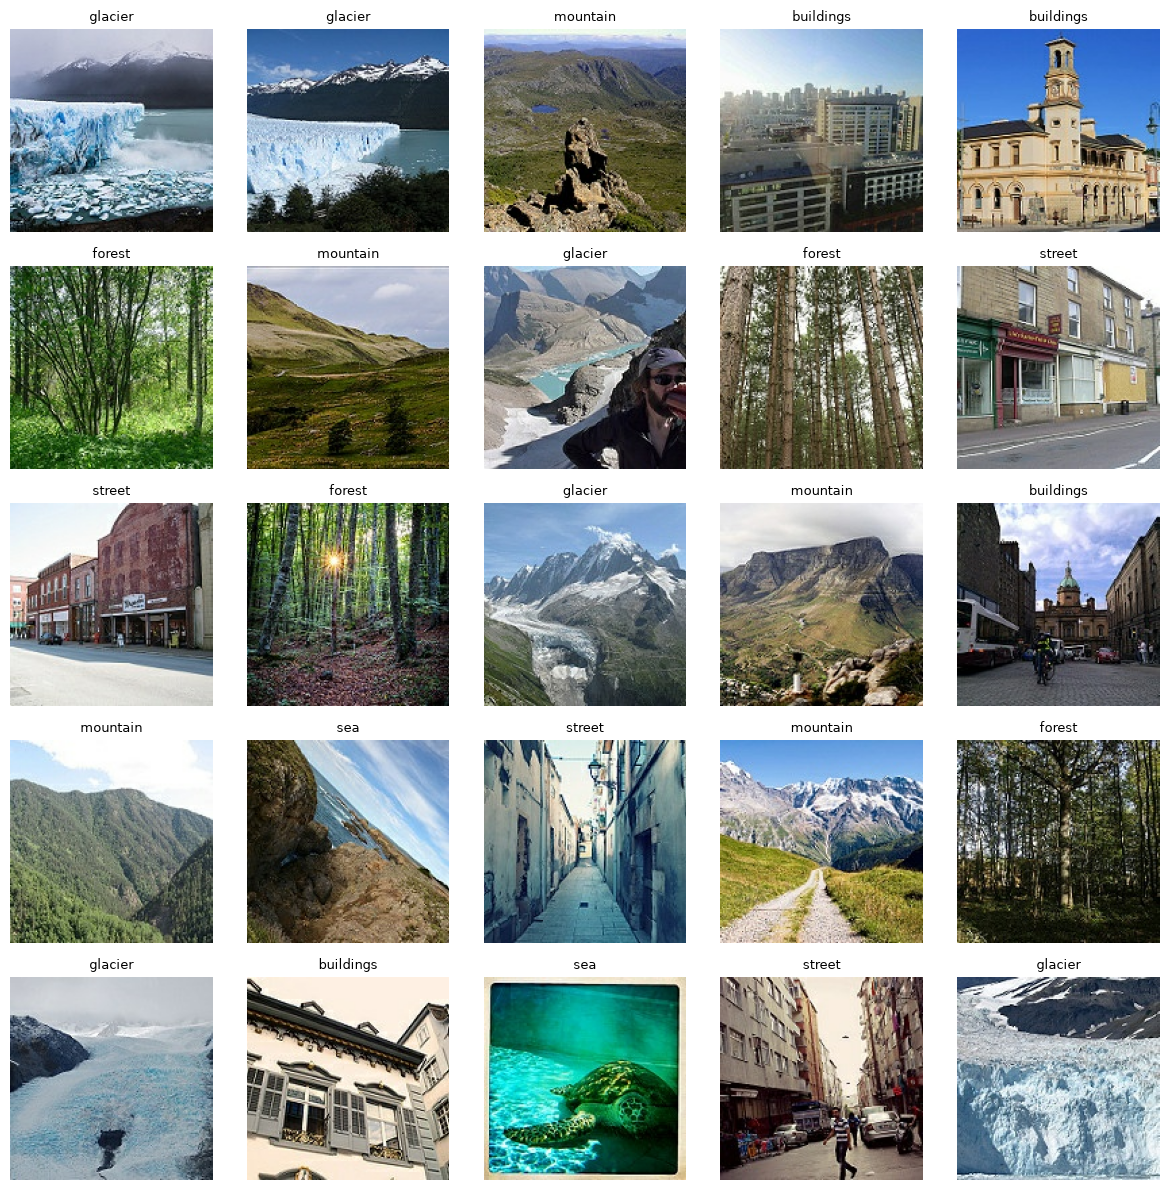

In [7]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

# Take one batch from the dataset
images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Prelude: Baseline CNN (reference model)

This is our **reference** network: two Conv→Pool blocks with channels **32 → 64**, followed by a **single hidden head** `Dense(64)`. We use **He** initialization for ReLU activations and include an **optional `Dropout(0.5)`** to illustrate regularization—comment it out to gauge its impact (ha, not really optional!). 

Use this model as a stable yardstick while you run **ablations**: change **one knob at a time** (e.g., widen/deepen the conv blocks, adjust dropout rate, add batch norm, tweak the LR schedule) and compare results back to this baseline. Focus on **training vs. validation curves**, the **generalization gap**, and how dropout affects **val loss/accuracy** and how long it takes for Early Stopping to kick in. 


> **Note:** On rare runs, training may become numerically unstable and produce `NaN` loss values. If this occurs, rerun the model. If the problem persists, restart the runtime and run the notebook again from the beginning.


Baseline Model



C:\Users\gjgut\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


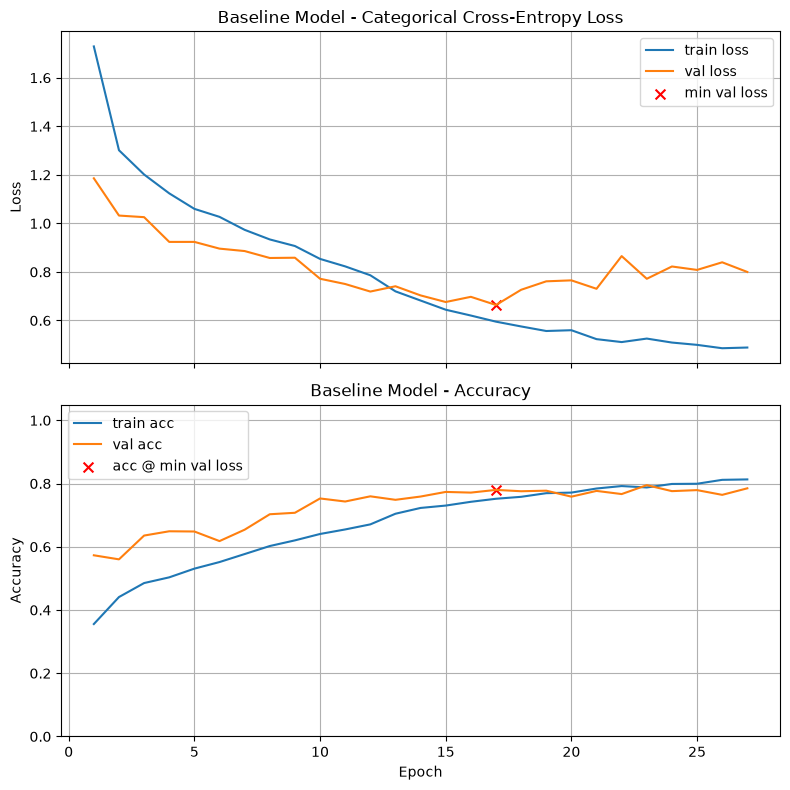

Final Training Loss:            0.4886
Final Training Accuracy:        0.8131
Final Validation Loss:          0.7999
Final Validation Accuracy:      0.7850
Minimum Validation Loss:        0.6638 (Epoch 17)
Validation Accuracy @ Min Loss: 0.7800



Test Loss: 0.7482
Test Accuracy: 0.7687

Validation-Test Gap (accuracy): 0.011290

Execution Time: 00:01:53


In [8]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model")


## Problem One: Exploring Basic Hyperparameters

**Task:**
Copy the baseline CNN model into the next cell and experiment with basic hyperparameter changes. Your goal is to see whether small tweaks can improve validation accuracy (and hopefully speed up convergence or produce smoother training curves). You must **pick 3 of the following tweaks** and investigate their effect:

**Tweaks to Try:**

1. Adjust the learning rate (default for Adam is `1e-3`).
2. Change the width of the `Conv2D` layers (e.g., 64 → 128).
3. Add an extra `Conv2D` layer (e.g., stack 32 → 64 → 128).
4. Change the width of the `Dense(64 ...)` layer. 
5. Add L2 regularization to the `Dense(64 ...)` layer (see the head of the network in Problem 5 for inspiration).  
6. Modify the dropout rate.
   
Observe the effect of each of your 3 choices in isolation and answer the graded questions.

**Optional:**
Combine two or more changes to see if they work together to improve results (example: try L2 regularization and reduced dropout in the head, as in Problem 5). 


**Pro Tip:** Give each experiment a descriptive title, such as "Problem 1 -- Tweak 1 -- lr: 0.0005" to keep track of your experiments (see last cell in the notebook).

In [9]:
he = initializers.HeNormal()

def build_cnn(conv_widths=(32, 64), dense_units=64, dropout=0.5, l2=None, batch_norm=False, pooling="flatten"):
    model = models.Sequential([Input(shape=INPUT_SHAPE)])
    for i, width in enumerate(conv_widths):
        model.add(Conv2D(width, (3, 3), activation="relu", kernel_initializer=he, padding="same"))
        if batch_norm:
            model.add(BatchNormalization())
        if pooling == "flatten" or i < len(conv_widths) - 1:
            model.add(MaxPooling2D(2))
    if pooling == "flatten":
        model.add(Flatten())
        model.add(Dense(dense_units, activation="relu", kernel_initializer=he, kernel_regularizer=l2))
        model.add(Dropout(dropout))
    else:
        model.add(GlobalAveragePooling2D())
    model.add(Dense(num_classes, activation="softmax"))
    return model


Problem 1 -- Tweak 1 -- lr: 0.0005



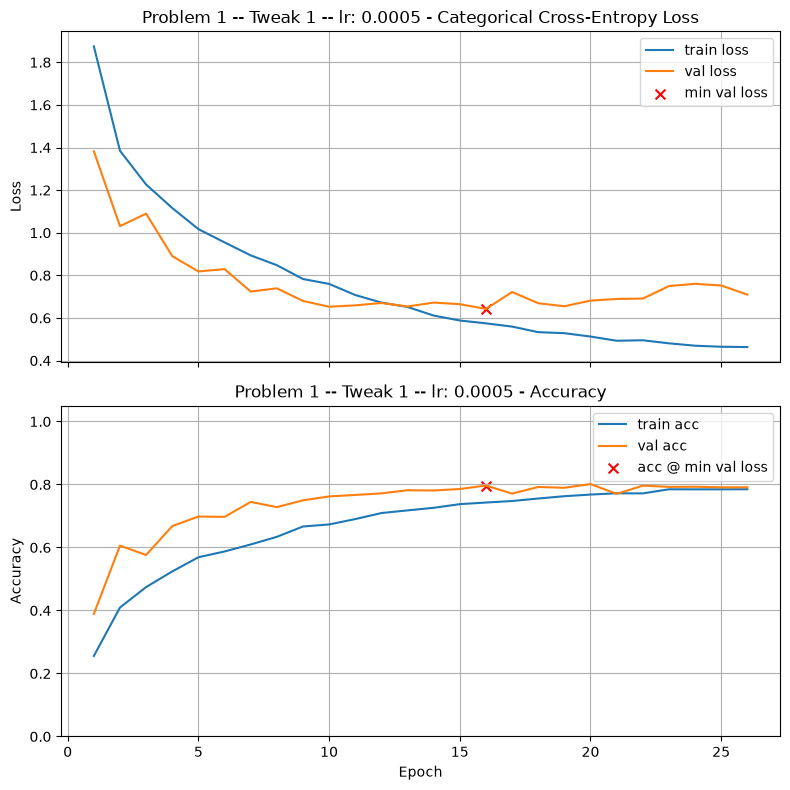

Final Training Loss:            0.4634
Final Training Accuracy:        0.7850
Final Validation Loss:          0.7097
Final Validation Accuracy:      0.7910
Minimum Validation Loss:        0.6423 (Epoch 16)
Validation Accuracy @ Min Loss: 0.7967



Test Loss: 0.7064
Test Accuracy: 0.7863

Validation-Test Gap (accuracy): 0.010386

Execution Time: 00:01:46


In [10]:
train_and_test(build_cnn(), lr_schedule=0.0005, title="Problem 1 -- Tweak 1 -- lr: 0.0005")


Problem 1 -- Tweak 2 -- conv widths: 64, 128



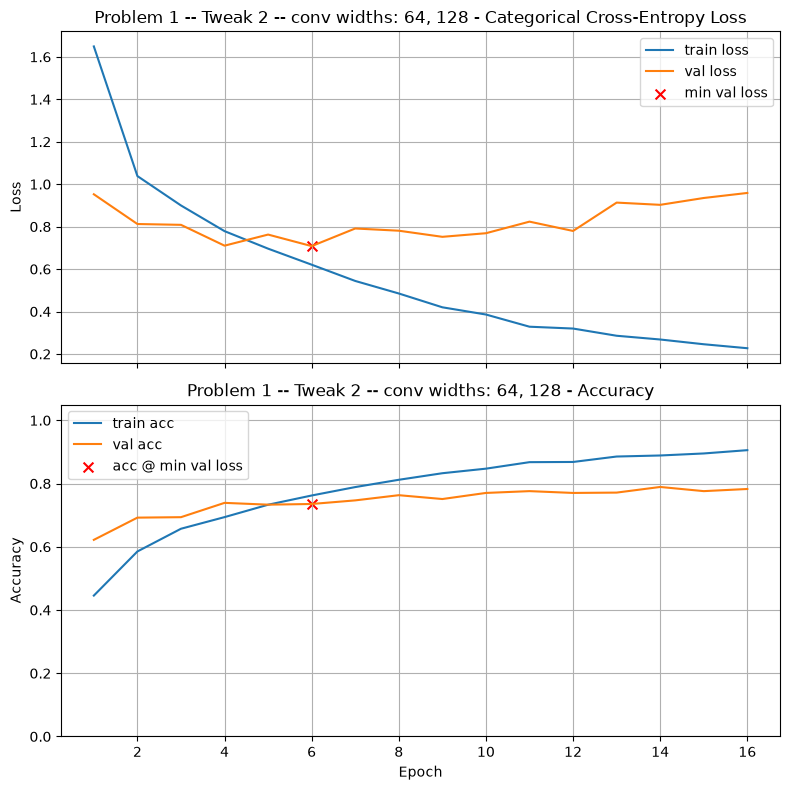

Final Training Loss:            0.2271
Final Training Accuracy:        0.9056
Final Validation Loss:          0.9587
Final Validation Accuracy:      0.7828
Minimum Validation Loss:        0.7083 (Epoch 6)
Validation Accuracy @ Min Loss: 0.7354



Test Loss: 0.7406
Test Accuracy: 0.7380

Validation-Test Gap (accuracy): 0.002622

Execution Time: 00:01:41


In [11]:
train_and_test(build_cnn(conv_widths=(64, 128)), title="Problem 1 -- Tweak 2 -- conv widths: 64, 128")


Problem 1 -- Tweak 3 -- extra Conv2D(128)



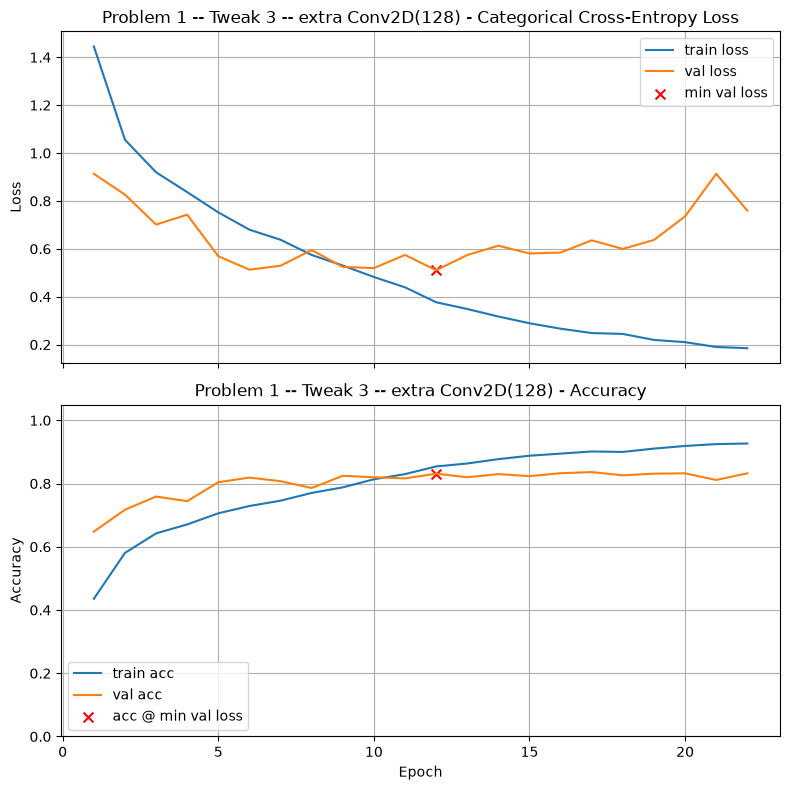

Final Training Loss:            0.1849
Final Training Accuracy:        0.9267
Final Validation Loss:          0.7597
Final Validation Accuracy:      0.8324
Minimum Validation Loss:        0.5107 (Epoch 12)
Validation Accuracy @ Min Loss: 0.8313



Test Loss: 0.5559
Test Accuracy: 0.8317

Validation-Test Gap (accuracy): 0.000354

Execution Time: 00:01:36


In [12]:
train_and_test(build_cnn(conv_widths=(32, 64, 128)), title="Problem 1 -- Tweak 3 -- extra Conv2D(128)")

### Graded Questions

In [13]:
a1a = 3

In [14]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 3


In [15]:
a1b = 0.8313

In [16]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.8313


## Problem Two: Adding Batch Normalization

**Task:**
Take your best model from Problem One and add a `BatchNormalization()` layer immediately after each `Conv2D` layer. Batch normalization helps stabilize training and can improve convergence. 

**Next Steps:**

* Train the model with batch normalization included after each `Conv2D` layer. 
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare the results to your earlier experiments and answer the graded questions.

**Optional:**
Try more than one hyperparameter change alongside batch normalization and see how they interact.




Problem 2 -- BatchNorm



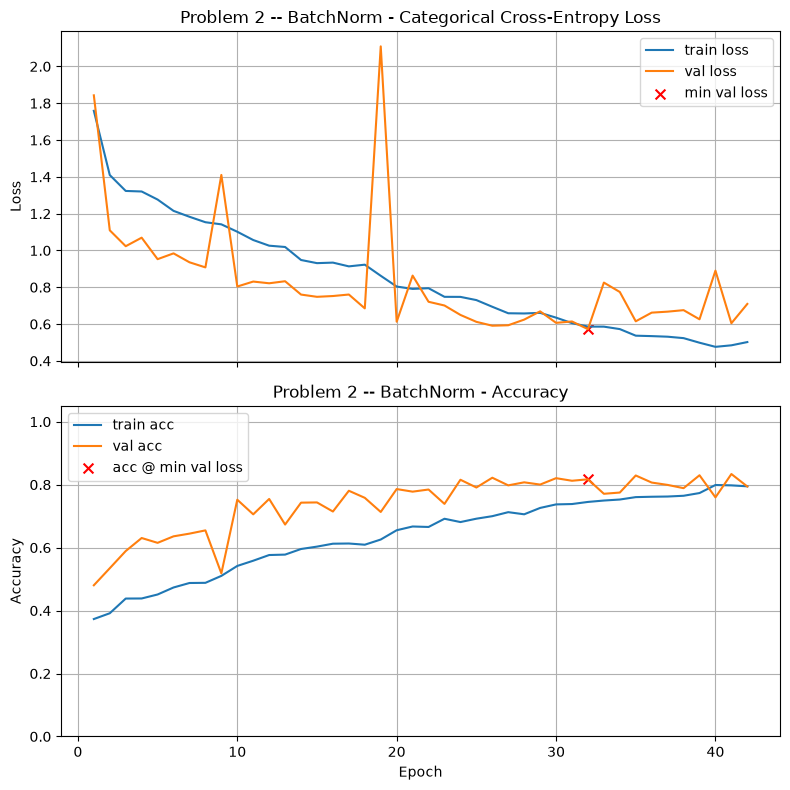

Final Training Loss:            0.5022
Final Training Accuracy:        0.7947
Final Validation Loss:          0.7094
Final Validation Accuracy:      0.7942
Minimum Validation Loss:        0.5722 (Epoch 32)
Validation Accuracy @ Min Loss: 0.8170



Test Loss: 0.5813
Test Accuracy: 0.8217

Validation-Test Gap (accuracy): 0.004620

Execution Time: 00:04:46


In [17]:
train_and_test(build_cnn(conv_widths=(32, 64, 128), batch_norm=True), title="Problem 2 -- BatchNorm")


Problem 2 -- BatchNorm -- Tweak 1 -- lr: 0.0005



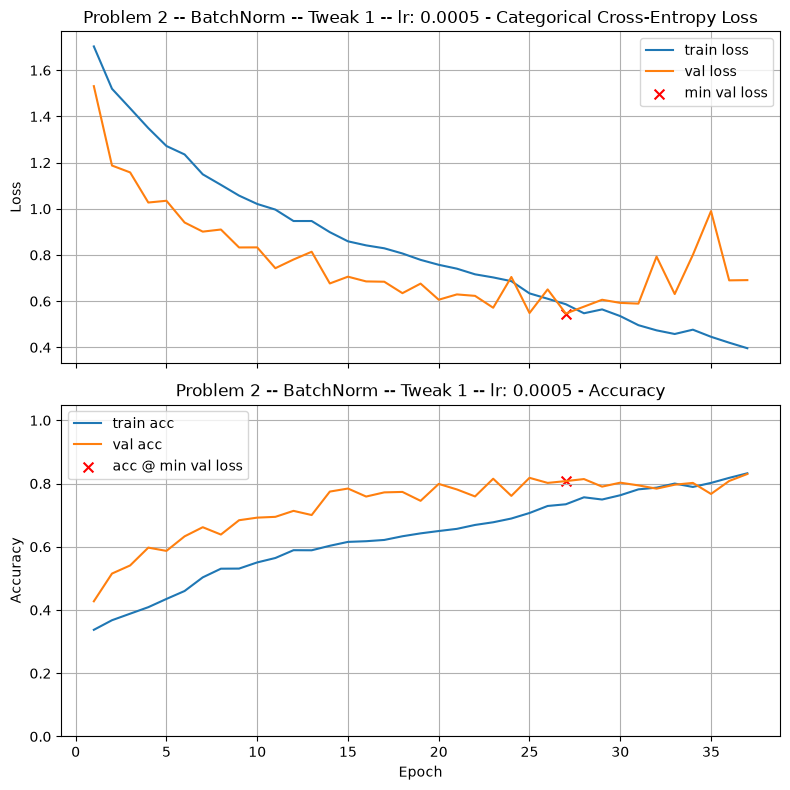

Final Training Loss:            0.3962
Final Training Accuracy:        0.8325
Final Validation Loss:          0.6912
Final Validation Accuracy:      0.8302
Minimum Validation Loss:        0.5465 (Epoch 27)
Validation Accuracy @ Min Loss: 0.8078



Test Loss: 0.5437
Test Accuracy: 0.8153

Validation-Test Gap (accuracy): 0.007559

Execution Time: 00:04:12


In [18]:
train_and_test(build_cnn(conv_widths=(32, 64, 128), batch_norm=True), lr_schedule=0.0005, title="Problem 2 -- BatchNorm -- Tweak 1 -- lr: 0.0005")


Problem 2 -- BatchNorm -- Tweak 6 -- dropout: 0.3



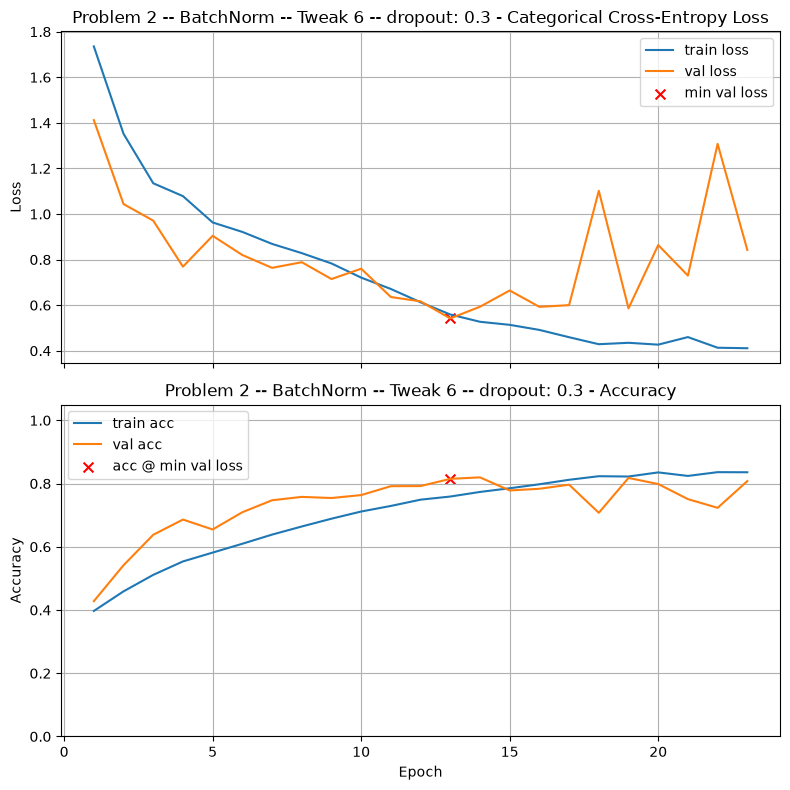

Final Training Loss:            0.4112
Final Training Accuracy:        0.8357
Final Validation Loss:          0.8423
Final Validation Accuracy:      0.8078
Minimum Validation Loss:        0.5418 (Epoch 13)
Validation Accuracy @ Min Loss: 0.8149



Test Loss: 0.5789
Test Accuracy: 0.8117

Validation-Test Gap (accuracy): 0.003241

Execution Time: 00:02:37


In [19]:
train_and_test(build_cnn(conv_widths=(32, 64, 128), batch_norm=True, dropout=0.3), title="Problem 2 -- BatchNorm -- Tweak 6 -- dropout: 0.3")

### Graded Questions

In [20]:
a2a = -1

In [21]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 


a2a = -1


In [22]:
a2b = 0.8170

In [23]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.8170


## Problem Three: Global Average Pooling

As we saw in this week's Coding Video, 
**Global Average Pooling** is a simple layer that replaces the `Flatten → Dense` part of a CNN (please review that part of the Coding Notebook, which contains a description of this important technique). 

In practice, swapping `Flatten` for `GlobalAveragePooling2D` often improves stability and validation performance — definitely worth considering!


**Task:**
Modify your best model from Problems 1 & 2 to use a `GlobalAveragePooling2D()` layer instead of a flatten-and-dense block. 

**Next Steps:**

* Replace the sequence between the last `Conv2D` and output layers, for example:

     
          MaxPooling2D((2, 2)),
          Flatten(),
          Dense(64, activation='relu', kernel_initializer=initializers.HeNormal()),
          Dropout(0.5),   

  with a single `GlobalAveragePooling2D()` layer.
* Train the model and observe how performance and training curves change.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare results and answer the graded questions.

**Optional:**
Experiment with `GlobalMaxPooling2D()` as an alternative and compare its behavior to `GlobalAveragePooling2D()`.




Problem 3 -- GAP



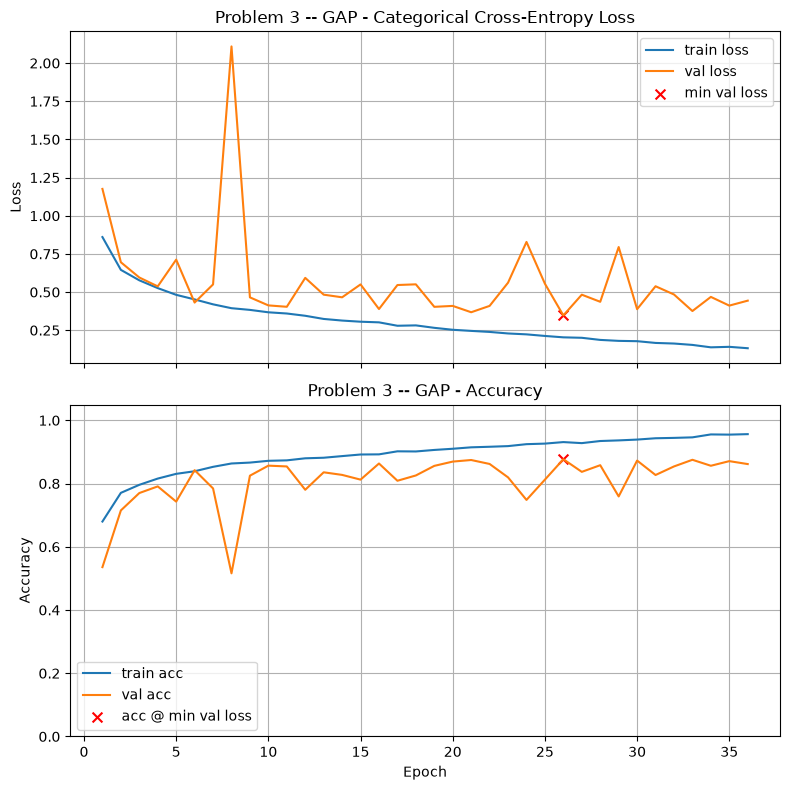

Final Training Loss:            0.1322
Final Training Accuracy:        0.9563
Final Validation Loss:          0.4439
Final Validation Accuracy:      0.8616
Minimum Validation Loss:        0.3469 (Epoch 26)
Validation Accuracy @ Min Loss: 0.8770



Test Loss: 0.3534
Test Accuracy: 0.8780

Validation-Test Gap (accuracy): 0.001039

Execution Time: 00:03:58


In [24]:
train_and_test(build_cnn(conv_widths=(32, 64, 128), batch_norm=True, pooling="gap"), title="Problem 3 -- GAP")


Problem 3 -- GAP -- Tweak 2 -- conv widths: 64, 128, 256



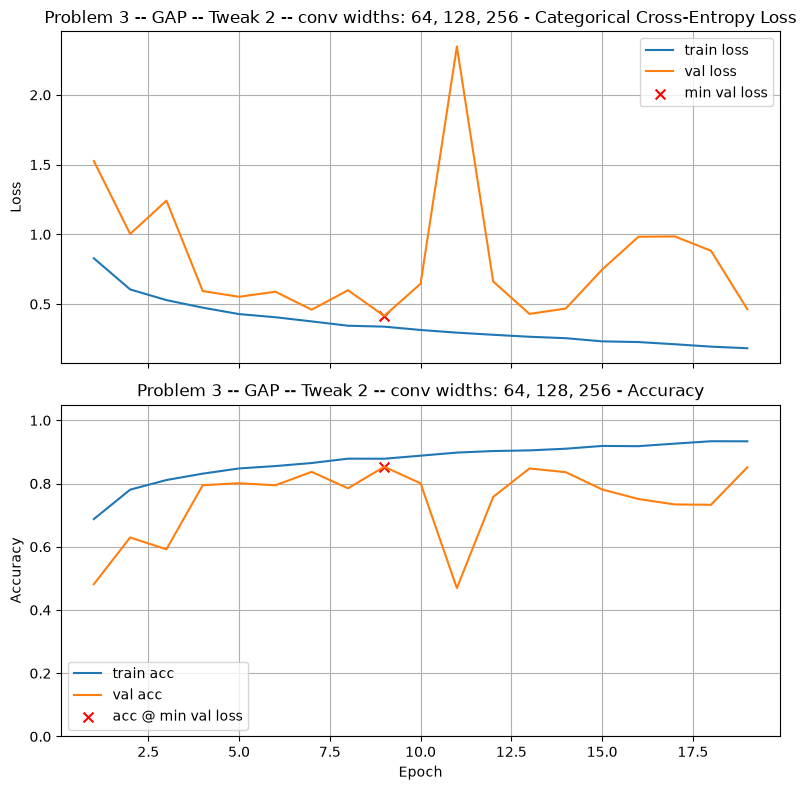

Final Training Loss:            0.1834
Final Training Accuracy:        0.9337
Final Validation Loss:          0.4628
Final Validation Accuracy:      0.8513
Minimum Validation Loss:        0.4151 (Epoch 9)
Validation Accuracy @ Min Loss: 0.8531



Test Loss: 0.4284
Test Accuracy: 0.8430

Validation-Test Gap (accuracy): 0.010067

Execution Time: 00:03:47


In [25]:
train_and_test(build_cnn(conv_widths=(64, 128, 256), batch_norm=True, pooling="gap"), title="Problem 3 -- GAP -- Tweak 2 -- conv widths: 64, 128, 256")


Problem 3 -- GAP -- Tweak 3 -- extra Conv2D(256)



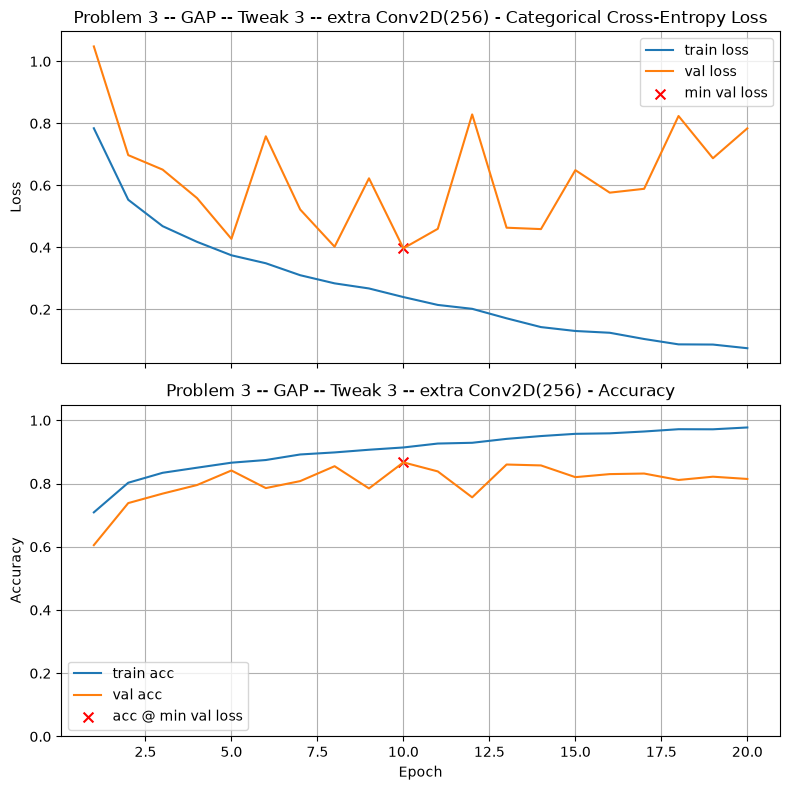

Final Training Loss:            0.0745
Final Training Accuracy:        0.9774
Final Validation Loss:          0.7838
Final Validation Accuracy:      0.8146
Minimum Validation Loss:        0.3968 (Epoch 10)
Validation Accuracy @ Min Loss: 0.8670



Test Loss: 0.4335
Test Accuracy: 0.8593

Validation-Test Gap (accuracy): 0.007642

Execution Time: 00:02:24


In [26]:
train_and_test(build_cnn(conv_widths=(32, 64, 128, 256), batch_norm=True, pooling="gap"), title="Problem 3 -- GAP -- Tweak 3 -- extra Conv2D(256)")

### Graded Questions

In [27]:
a3a = -1

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 


a3a = -1


In [29]:
a3b = 0.8770

In [30]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.8770


## Problem Four: ReduceLROnPlateau

`ReduceLROnPlateau` is a widely used learning rate scheduling technique. It monitors a validation metric (usually `val_loss`) and reduces the learning rate when progress stalls, allowing the model to refine training at a smaller step size. This is one of the most useful scheduling tools (along with the essential Early Stopping) to have in your toolbox.

**Task:**
Augment your best model found so far in Problems 1 - 3 with the `ReduceLROnPlateau` callback during training.

**Next Steps:**

* Add the callback parameter to `train_and_test`:

  ```python
  callbacks=[reduce_lr]
  ```

* Start with **`factor=0.5`** (monitor `val_loss`, `patience=2–3`, `cooldown=1`, `min_lr=1e-5` for Adam).
* **Practical playbook:**

  * If plateau persists after one reduction → try **`factor=0.3`**, then **`0.2`**.
  * If a reduction hurts validation noticeably → try **`factor=0.7–0.8`** or increase **`patience`**.
  * Leave **`cooldown=1`** unless you see too-frequent drops.
* Experiment with **`patience` = 3, 5, 8** and **`min_delta` = `1e-4` vs `1e-3`** to gauge sensitivity.
* Choose the configuration with the best validation results—or note that ReduceLROnPlateau didn’t help (rare!). 
* Answer the graded questions.



In [31]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

# Your code here, add more cells as needed


Problem 4 -- ReduceLROnPlateau -- factor: 0.5



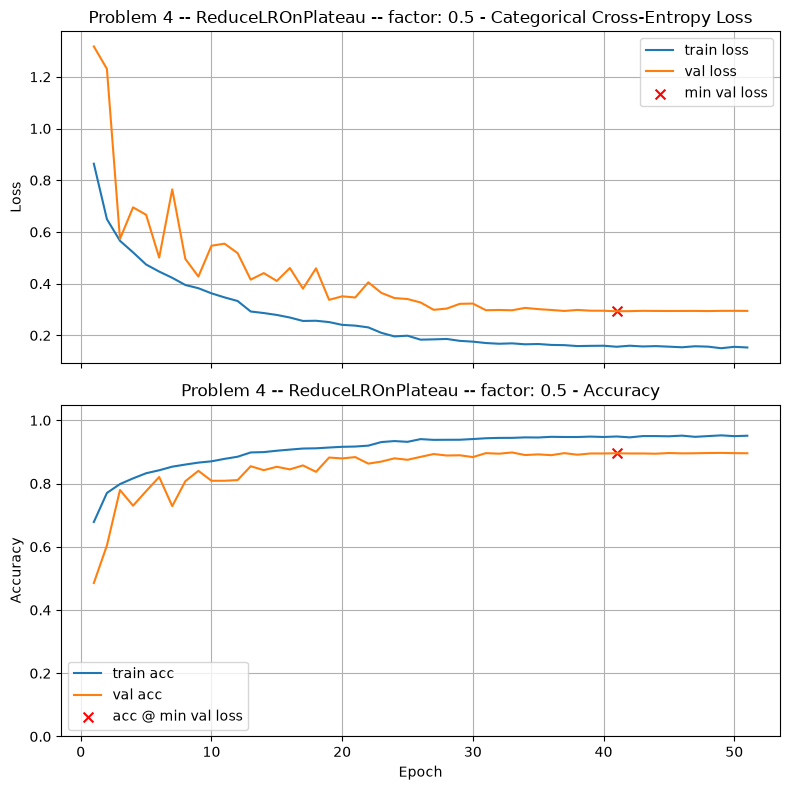

Final Training Loss:            0.1533
Final Training Accuracy:        0.9513
Final Validation Loss:          0.2948
Final Validation Accuracy:      0.8959
Minimum Validation Loss:        0.2934 (Epoch 41)
Validation Accuracy @ Min Loss: 0.8959



Test Loss: 0.2976
Test Accuracy: 0.8960

Validation-Test Gap (accuracy): 0.000137

Execution Time: 00:05:39


In [32]:
train_and_test(build_cnn(conv_widths=(32, 64, 128), batch_norm=True, pooling="gap"), callbacks=[reduce_lr], title="Problem 4 -- ReduceLROnPlateau -- factor: 0.5")


Problem 4 -- ReduceLROnPlateau -- factor: 0.3



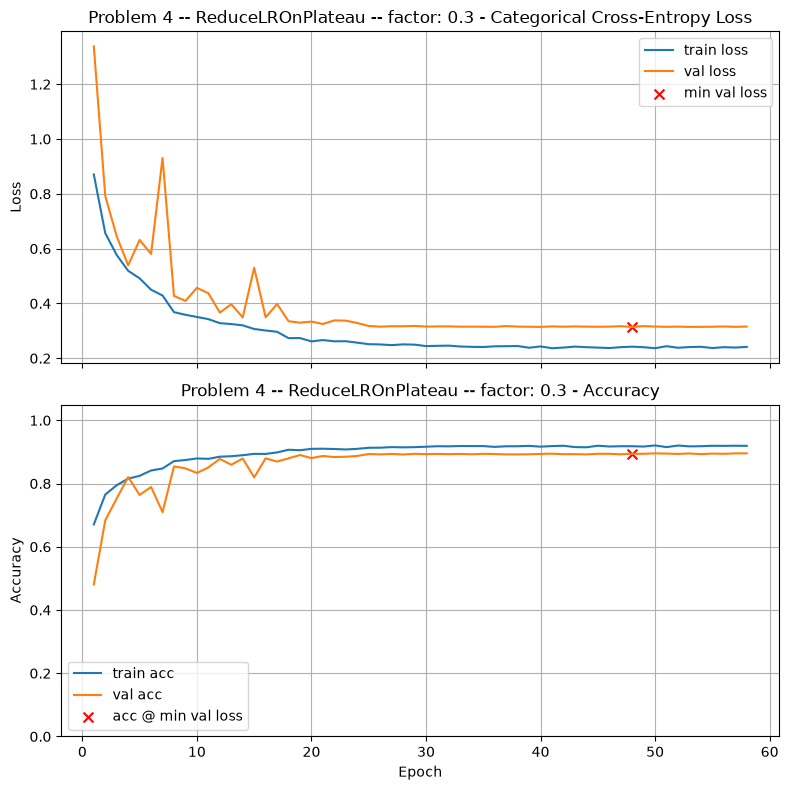

Final Training Loss:            0.2415
Final Training Accuracy:        0.9192
Final Validation Loss:          0.3157
Final Validation Accuracy:      0.8955
Minimum Validation Loss:        0.3142 (Epoch 48)
Validation Accuracy @ Min Loss: 0.8941



Test Loss: 0.2985
Test Accuracy: 0.8957

Validation-Test Gap (accuracy): 0.001587

Execution Time: 00:06:24


In [33]:
reduce_lr_03 = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_delta=1e-4, cooldown=1, min_lr=1e-5, verbose=0)
train_and_test(build_cnn(conv_widths=(32, 64, 128), batch_norm=True, pooling="gap"), callbacks=[reduce_lr_03], title="Problem 4 -- ReduceLROnPlateau -- factor: 0.3")


Problem 4 -- ReduceLROnPlateau -- factor: 0.7



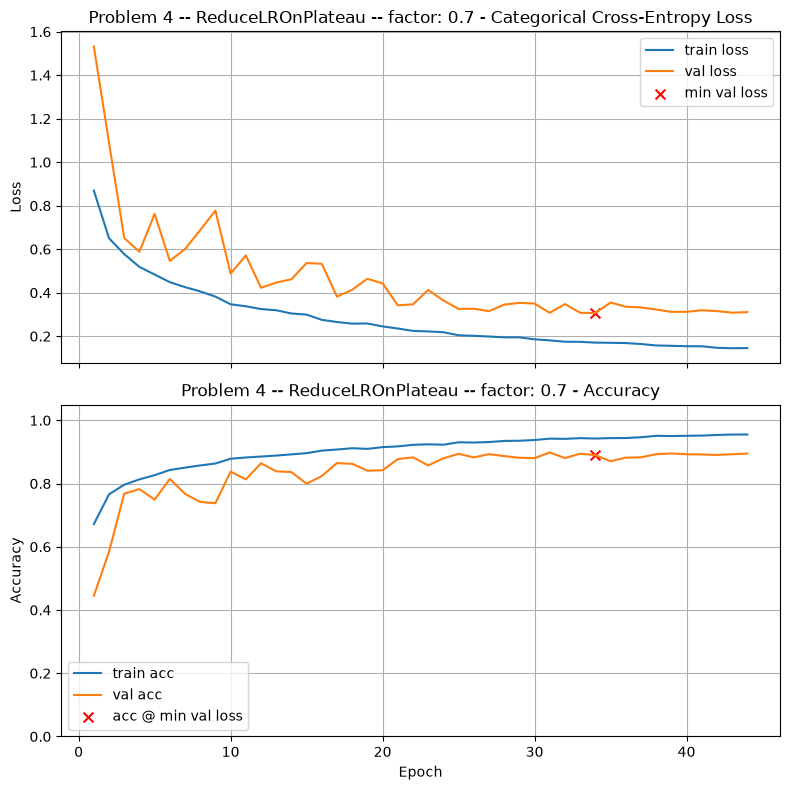

Final Training Loss:            0.1455
Final Training Accuracy:        0.9551
Final Validation Loss:          0.3107
Final Validation Accuracy:      0.8948
Minimum Validation Loss:        0.3069 (Epoch 34)
Validation Accuracy @ Min Loss: 0.8898



Test Loss: 0.3043
Test Accuracy: 0.8923

Validation-Test Gap (accuracy): 0.002533

Execution Time: 00:04:51


In [34]:
reduce_lr_07 = ReduceLROnPlateau(monitor='val_loss', factor=0.7, patience=3, min_delta=1e-4, cooldown=1, min_lr=1e-5, verbose=0)
train_and_test(build_cnn(conv_widths=(32, 64, 128), batch_norm=True, pooling="gap"), callbacks=[reduce_lr_07], title="Problem 4 -- ReduceLROnPlateau -- factor: 0.7")

### Graded Questions

In [35]:
a4a = 0.5

In [36]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.2f}') 

a4a = 0.50


In [37]:
a4b = 0.8959

In [38]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8959


## Problem Five: A Very Deep CNN (VGG-16 Style)

 We will now experiment with the VGG-16 design introduced in the Coding Notebook and Video and see how it does on this dataset. For a beautiful description of the model and its significance, see [Explanation of VGG-16](https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/) :
        

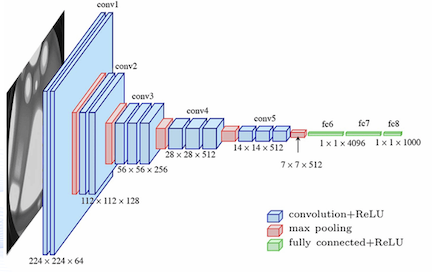


In this exercise you’ll **only vary the learning rate**. Don’t change any other hyperparameters. Your goal is to observe how LR affects convergence speed, stability, and final validation performance compared to your smaller baselines. This sets up next week’s **transfer learning** with pretrained models.

#### Starting point

* Optimizer: **Adam**
* **Recommended LR to start:** `1e-3`(Adam default)

#### What LR values to try (coarse → fine)

Try a short sweep like:

```
[1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
```

Then, as time allows,  zoom in around the best.

#### How to judge “best”

* Primary: **best validation accuracy at epoch of lowest validation loss** 
* Secondary: **time-to-best** (fewer epochs to reach a strong val metric) and **curve shape** (smooth vs. noisy/oscillatory).

#### What symptoms mean

* **LR too high:** training loss spikes or oscillates; val metrics erratic, occasional NaNs/divergence.
* **LR too low:** very slow improvement; long flat regions; never reaches your smaller models’ performance.


**Tip:** Keep LR **constant** during each run (don’t schedule) so you isolate its effect. 




VGG-style Large



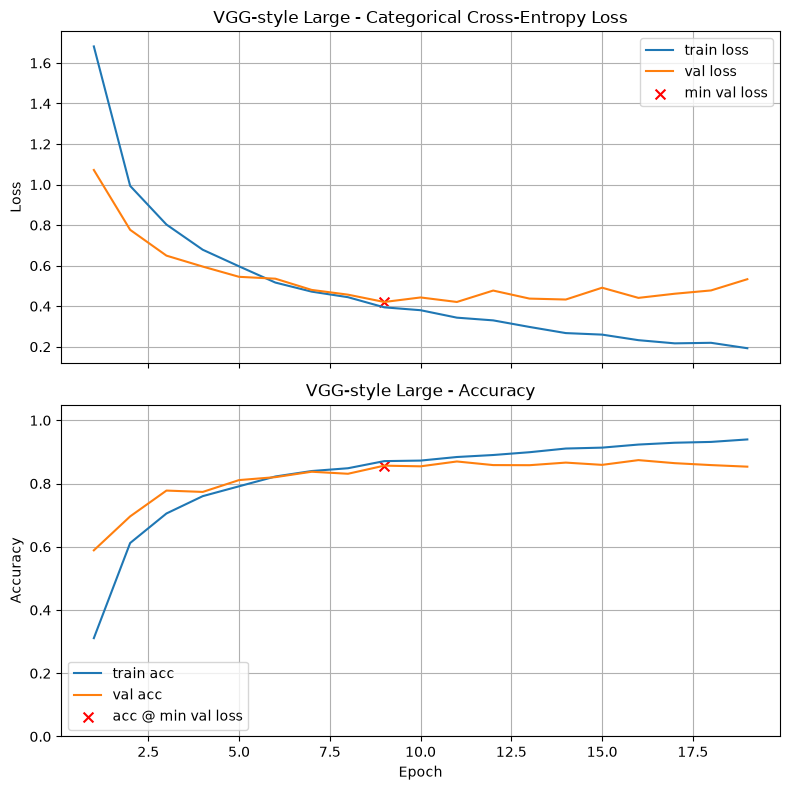

Final Training Loss:            0.1927
Final Training Accuracy:        0.9395
Final Validation Loss:          0.5332
Final Validation Accuracy:      0.8534
Minimum Validation Loss:        0.4208 (Epoch 9)
Validation Accuracy @ Min Loss: 0.8566



Test Loss: 0.4197
Test Accuracy: 0.8563

Validation-Test Gap (accuracy): 0.000300

Execution Time: 00:06:07


In [39]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16, lr_schedule=1e-3, epochs=30, title="VGG-style Large")



Problem 5 -- VGG-16 -- lr: 0.003



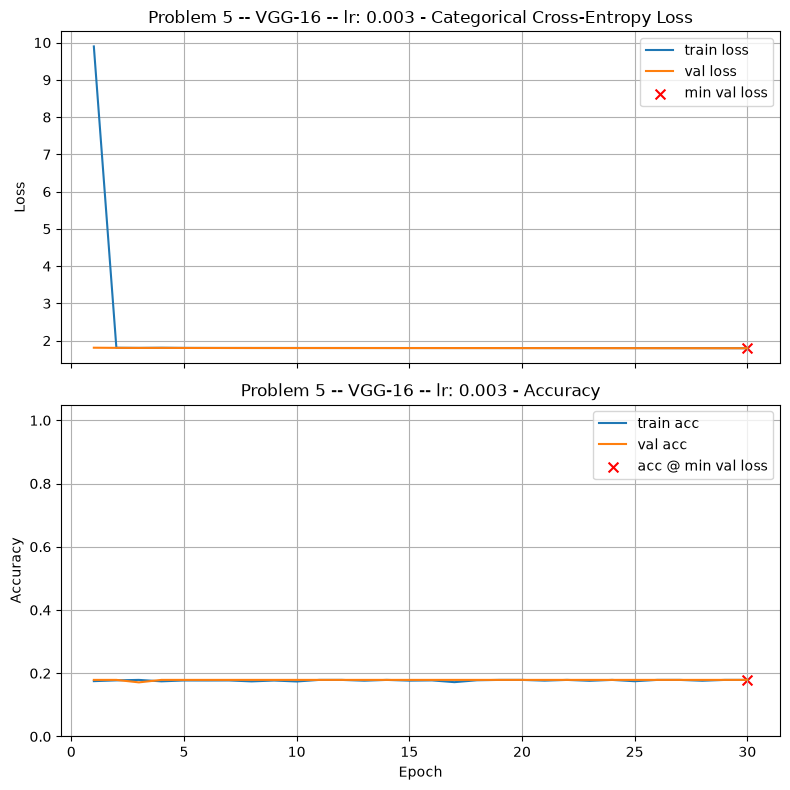

Final Training Loss:            1.7967
Final Training Accuracy:        0.1790
Final Validation Loss:          1.7961
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.7961 (Epoch 30)
Validation Accuracy @ Min Loss: 0.1790



Test Loss: 1.7958
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 00:09:37


In [40]:
train_and_test(models.clone_model(model_vgg_16), lr_schedule=0.003, epochs=30, title="Problem 5 -- VGG-16 -- lr: 0.003")


Problem 5 -- VGG-16 -- lr: 0.0003



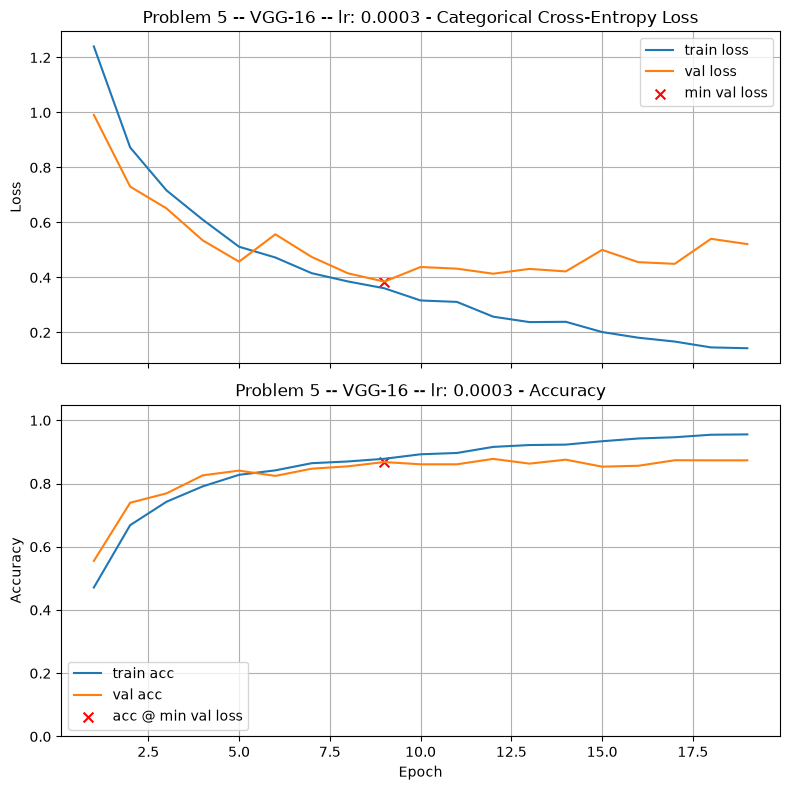

Final Training Loss:            0.1427
Final Training Accuracy:        0.9555
Final Validation Loss:          0.5214
Final Validation Accuracy:      0.8734
Minimum Validation Loss:        0.3849 (Epoch 9)
Validation Accuracy @ Min Loss: 0.8680



Test Loss: 0.3939
Test Accuracy: 0.8667

Validation-Test Gap (accuracy): 0.001379

Execution Time: 00:06:07


In [41]:
train_and_test(models.clone_model(model_vgg_16), lr_schedule=0.0003, epochs=30, title="Problem 5 -- VGG-16 -- lr: 0.0003")


Problem 5 -- VGG-16 -- lr: 0.0001



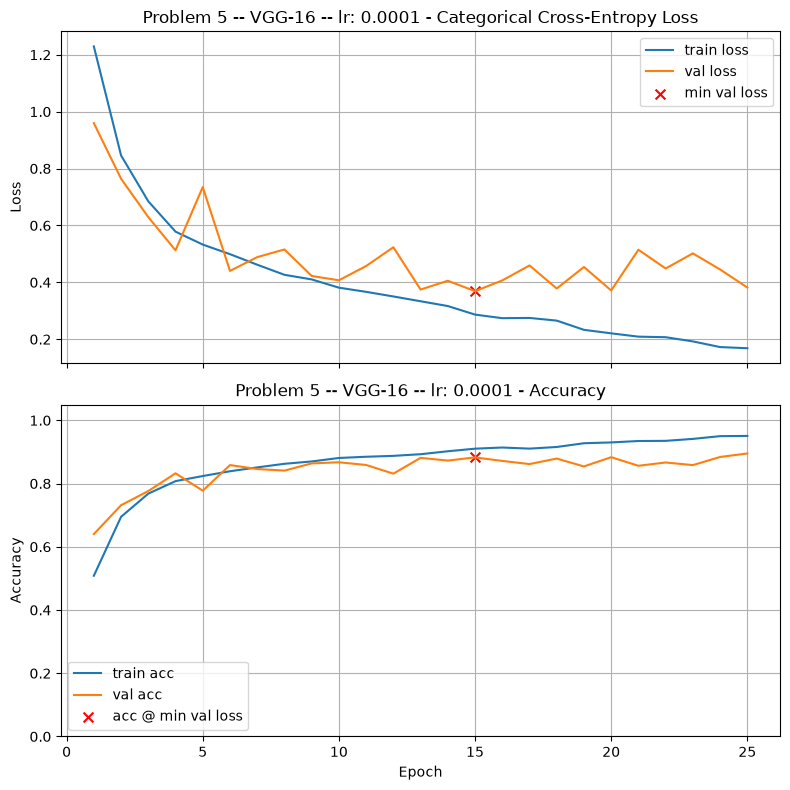

Final Training Loss:            0.1685
Final Training Accuracy:        0.9507
Final Validation Loss:          0.3819
Final Validation Accuracy:      0.8951
Minimum Validation Loss:        0.3691 (Epoch 15)
Validation Accuracy @ Min Loss: 0.8827



Test Loss: 0.3831
Test Accuracy: 0.8793

Validation-Test Gap (accuracy): 0.003334

Execution Time: 00:08:03


In [42]:
train_and_test(models.clone_model(model_vgg_16), lr_schedule=0.0001, epochs=30, title="Problem 5 -- VGG-16 -- lr: 0.0001")

### Graded Questions

In [43]:
a5a = 0.0001

In [44]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.8f}') 

a5a = 0.00010000


In [45]:
a5b = 0.8827

In [46]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8827


## All Results

This will print out the results from all experiments, with titles as keys. I use this all the time to keep track of experiments!

In [47]:
print_results()

Problem 4 -- ReduceLROnPlateau -- factor: 0.5	0.8959	41
Problem 4 -- ReduceLROnPlateau -- factor: 0.3	0.8941	48
Problem 4 -- ReduceLROnPlateau -- factor: 0.7	0.8898	34
Problem 5 -- VGG-16 -- lr: 0.0001       	0.8827	15
Problem 3 -- GAP                        	0.8770	26
Problem 5 -- VGG-16 -- lr: 0.0003       	0.8680	9
Problem 3 -- GAP -- Tweak 3 -- extra Conv2D(256)	0.8670	10
VGG-style Large                         	0.8566	9
Problem 3 -- GAP -- Tweak 2 -- conv widths: 64, 128, 256	0.8531	9
Problem 1 -- Tweak 3 -- extra Conv2D(128)	0.8313	12
Problem 2 -- BatchNorm                  	0.8170	32
Problem 2 -- BatchNorm -- Tweak 6 -- dropout: 0.3	0.8149	13
Problem 2 -- BatchNorm -- Tweak 1 -- lr: 0.0005	0.8078	27
Problem 1 -- Tweak 1 -- lr: 0.0005      	0.7967	16
Baseline Model                          	0.7800	17
Problem 1 -- Tweak 2 -- conv widths: 64, 128	0.7354	6
Problem 5 -- VGG-16 -- lr: 0.003        	0.1790	30
